# Sasa & Dany · Milestone 1 · Pre-cleaning profile

**What this notebook is:** the exploratory data analysis (EDA) we do *before* any cleaning, for 11 of the 14 tables:
`seasons`, `circuits`, `drivers`, `constructors`, `status`, `sprint_results`, `driver_standings`,
`lap_times`, `pit_stops`, `constructor_standings`, `constructor_results`.

**Why:** the brief asks for EDA before cleaning, backed by code and plots instead of looking at rows by eye.
What we find here decides how each table is cleaned later, and feeds the data-engineering questions,
the features and the report.

**One rule for the whole notebook:** the raw files are never changed. Every step works on copies.

## P0 · Setup: load untouched, fingerprint, build helpers

- **What:** load our 11 CSV files exactly as delivered (every column as text), save a fingerprint of each one, and define four helper functions.
- **Why:**
  - Reading everything as text keeps the `\N` placeholders visible, so we can count them instead of letting pandas hide them.
  - The fingerprint lets us prove at the end (step D3) that the raw data was never modified, as the brief requires.
  - The helpers (`as_num`, `year_of`, `profile`, `pk_check`) make every later step use the same checks, so our EDA is code, not manual inspection.

In [1]:
# ==========================================================================================
# P0 · SETUP: load our 11 tables exactly as they are, and build the helpers every step uses
# ==========================================================================================

# ---------- 1. Libraries ----------
import os                          # to find the folder where Kaggle put the dataset
import numpy as np                 # gives us NaN, the real "missing value" marker
import pandas as pd                # tables (DataFrames): reading, counting, grouping
import matplotlib.pyplot as plt    # basic plots
import seaborn as sns              # nicer statistical plots (heatmaps, etc.)

pd.set_option("display.max_columns", 50)   # show every column when we display a table

# Library versions: Kaggle's versions can differ from our laptops, so we print them for reproducibility
print("pandas", pd.__version__, "| numpy", np.__version__, "| seaborn", sns.__version__)


# ---------- 2. Where is the data? ----------
# Kaggle puts attached datasets somewhere under /kaggle/input. Instead of guessing the exact
# folder name, we search for the folder that contains races.csv. On a laptop we fall back to ./data
def find_data_dir():
    for folder, _, files in os.walk("/kaggle/input"):
        if "races.csv" in files:
            return folder
    return "data"

DATA_DIR = find_data_dir()
csv_files = sorted(f for f in os.listdir(DATA_DIR) if f.endswith(".csv"))
print("Data folder:", DATA_DIR)
print("CSV files found:", len(csv_files))          # we expect 14


# ---------- 3. The 11 tables we (Sasa & Dany) profile ----------
# races, results and qualifying are profiled by our teammates; we only read them for lookups.
MINE = ["seasons", "circuits", "drivers", "constructors", "status", "sprint_results",
        "driver_standings", "lap_times", "pit_stops", "constructor_standings", "constructor_results"]

# The dataset does not leave missing cells empty: it writes the text \N instead.
# A value that "stands in" for missing like this is called a sentinel.
SENT = r"\N"


# ---------- 4. Load every file exactly as it is (the "bronze" layer) ----------
# dtype=str              -> read every column as text, so pandas does not guess the types for us
# keep_default_na=False  -> pandas must not turn anything into NaN by itself, so \N stays visible
raw = {t: pd.read_csv(f"{DATA_DIR}/{t}.csv", dtype=str, keep_default_na=False)
       for t in MINE + ["races", "results"]}

# A fingerprint (hash) of every raw table. In step D3 we compute it again and compare,
# to PROVE we never changed the raw data (the brief: "Raw CSV files remain immutable").
RAW_HASH = {t: pd.util.hash_pandas_object(df).sum() for t, df in raw.items()}


# ---------- 5. Two lookups we need in many steps ----------
# races: turn \N into NaN and make ids and year numeric, so we can find the season of any raceId
races = raw["races"].replace(SENT, np.nan).astype({"raceId": int, "year": int, "round": int, "circuitId": int})
races["date"] = pd.to_datetime(races["date"])      # race date as a real date, not text
YEAR = races.set_index("raceId")["year"]           # quick lookup: raceId -> season year
results = raw["results"].replace(SENT, np.nan)     # results with \N as NaN, used only for cross-checks


# ---------- 6. Helper functions (the same checks for every table) ----------
def as_num(df):
    # Returns a COPY for exploring: \N becomes NaN, and every column made only of numbers becomes numeric.
    # Columns that contain any text (e.g. lap times like "1:26.572") stay text, so we can still see their format.
    out = df.replace(SENT, np.nan)
    for c in out.columns:
        conv = pd.to_numeric(out[c], errors="coerce")     # try to read the column as numbers
        if conv.notna().sum() == out[c].notna().sum():    # did EVERY non-missing value convert?
            out[c] = conv                                 # yes -> keep the numeric version
    return out


def year_of(df):
    # The season year of every row, for any table that has a raceId column
    return pd.to_numeric(df["raceId"]).map(YEAR)


def profile(t):
    # A "profile card" for table t: one row per column, with the checks we care about
    df = raw[t]
    return pd.DataFrame({
        "sentinel_N": df.eq(SENT).sum(),                     # how many \N in the column
        "sentinel_%": (df.eq(SENT).mean() * 100).round(2),   # the same, as a % of the rows
        "empty_str": df.eq("").sum(),                        # truly empty cells (we expect 0)
        "unique": df.nunique(),                              # how many different values
        "numeric_%": df.apply(lambda s: pd.to_numeric(s, errors="coerce").notna().mean() * 100).round(1),  # % that read as numbers
        "example": df.iloc[0]})                              # the first value, to see the format


def pk_check(t, cols):
    # Checks a primary key: the column(s) that should identify each row of table t
    df = raw[t]
    return {"table": t, "key": "+".join(cols), "rows": len(df),
            "duplicates": int(df.duplicated(cols).sum()),                          # rows whose key appears again
            "null_or_sentinel": int(df[cols].isin(["", SENT]).any(axis=1).sum())}  # rows with a missing key


# ---------- 7. First output: how big is each of our 11 tables? ----------
sizes = pd.DataFrame({t: raw[t].shape for t in MINE}, index=["rows", "columns"]).T
sizes

pandas 2.3.3 | numpy 2.1.3 | seaborn 0.13.2
Data folder: /kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020
CSV files found: 14


,rows,columns
seasons,75,2
circuits,77,9
drivers,861,9
constructors,212,5
status,139,2
sprint_results,360,16
driver_standings,34863,7
lap_times,589081,6
pit_stops,11371,7
constructor_standings,13391,7


**P0 result:** the dataset folder holds all 14 CSV files, and our 11 tables loaded with the sizes above.
`lap_times` is by far the biggest (589,081 rows); `seasons` and `status` are tiny lookup lists.
Nothing has been cleaned or changed; this is the starting point every later step builds on.

## A1 · seasons: complete list of years, and how season length changed

- **What:** profile the `seasons` table, check that its key (`year`) is unique and complete from 1950 to 2024, compare it with `races`, and plot how many races each season had.
- **Why:**
  - `seasons` is the list of years every other table relies on. A missing or repeated year would break joins and per-season counts.
  - Season length matters later: 5 wins in a 7-race season is not the same as 5 wins in a 24-race season, so we need to know how much it changed.

,sentinel_N,sentinel_%,empty_str,unique,numeric_%,example
year,0,0.0,0,75,100.0,2009
url,0,0.0,0,75,0.0,http://en.wikipedia.org/wiki/2009_Formula_One_...


{'table': 'seasons', 'key': 'year', 'rows': 75, 'duplicates': 0, 'null_or_sentinel': 0}
Every year 1950-2024 present: True
File order starts with: [2009, 2008, 2007] | sorted by year: False
Seasons with no races: set() | Race years missing from seasons: set()
url unique per season: True | every url contains its own year: True | example: http://en.wikipedia.org/wiki/2009_Formula_One_season
Fewest races in a season: 7 | most: 24
Seasons with the fewest races: [1950, 1955]
Seasons with the most races: [2024]


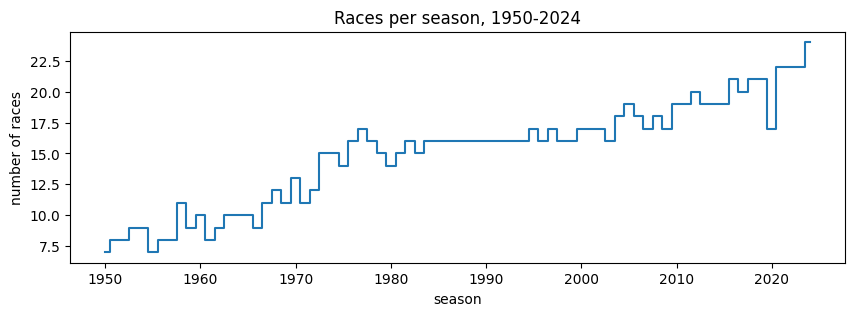

In [2]:
# ==========================================================================================
# A1 · seasons: is the list of years complete, and how did the length of a season change?
# ==========================================================================================

# An exploring copy of seasons: \N -> NaN and number columns -> numbers (raw stays untouched)
se = as_num(raw["seasons"])

# ---------- 1. Profile card: one row per column ----------
# Shows, for each column, how many \N there are, how many different values, and an example value
display(profile("seasons"))

# ---------- 2. Primary key: does "year" identify every row? ----------
# A good key has no repeated values and no missing values
print(pk_check("seasons", ["year"]))

# ---------- 3. Is every season from 1950 to 2024 there, with no gaps? ----------
print("Every year 1950-2024 present:", sorted(se.year) == list(range(1950, 2025)))

# ---------- 4. Is the file sorted by year? ----------
# We print the first 3 years in the order they appear in the file
print("File order starts with:", se.year.head(3).tolist(),
      "| sorted by year:", se.year.is_monotonic_increasing)

# ---------- 5. Do seasons and races agree with each other? ----------
# Every season should have races, and every year that has races should be in seasons
print("Seasons with no races:", set(se.year) - set(races.year),
      "| Race years missing from seasons:", set(races.year) - set(se.year))

# ---------- 6. What is the url column? ----------
# If every url is different and simply contains its own year, it is only a Wikipedia link, not data
print("url unique per season:", se.url.is_unique,
      "| every url contains its own year:", all(str(y) in u for y, u in zip(se.year, se.url)),
      "| example:", se.url.iloc[0])

# ---------- 7. How long was each season? ----------
races_per_season = races.groupby("year").size()          # number of races in each season
print("Fewest races in a season:", races_per_season.min(), "| most:", races_per_season.max())
print("Seasons with the fewest races:", list(races_per_season[races_per_season == races_per_season.min()].index))
print("Seasons with the most races:", list(races_per_season[races_per_season == races_per_season.max()].index))

# ---------- 8. Plot: races per season (saved for the report) ----------
ax = races_per_season.plot(drawstyle="steps-mid", figsize=(10, 3), title="Races per season, 1950-2024")
ax.set_xlabel("season")
ax.set_ylabel("number of races")
os.makedirs("figures", exist_ok=True)                                     # folder for all report figures
plt.savefig("figures/A1_races_per_season.png", dpi=120, bbox_inches="tight")
plt.show()

**A1 result:**
- 75 rows, one per season from 1950 to 2024: no gaps, no repeats, no `\N`, nothing empty. `year` is a valid primary key.
- The file is **not sorted**: it starts 2009, 2008, 2007.
- `seasons` and `races` agree perfectly: every season has races, and every race year is listed.
- `url` is only a Wikipedia link (different for every season and always containing its own year). It carries no information for the model.
- Season length grew from **7 races** (1950 and 1955) to **24 races** (2024).

**Decisions for cleaning:** sort by `year`; drop or ignore `url`; whenever we count something per season (wins, podiums, points), turn it into a rate or share, because seasons range from 7 to 24 races.

## A2 · circuits: profile, keys and types

- **What:** profile the `circuits` table, check its key and the other identifier columns, confirm each column's type, check that the coordinates are physically possible, and look for text problems (extra spaces, odd names, broken accents).
- **Why:** `circuits` is a lookup table: every race points to one circuit, question 1 ranks circuits, and question 2 uses their country. A broken key or a wrongly typed column here would silently break those joins later.

,sentinel_N,sentinel_%,empty_str,unique,numeric_%,example
circuitId,0,0.0,0,77,100.0,1
circuitRef,0,0.0,0,77,0.0,albert_park
name,0,0.0,0,77,0.0,Albert Park Grand Prix Circuit
location,0,0.0,0,75,0.0,Melbourne
country,0,0.0,0,35,0.0,Australia
lat,0,0.0,0,77,100.0,-37.8497
lng,0,0.0,0,77,100.0,144.968
alt,0,0.0,0,66,100.0,10
url,0,0.0,0,77,0.0,http://en.wikipedia.org/wiki/Melbourne_Grand_P...


{'table': 'circuits', 'key': 'circuitId', 'rows': 77, 'duplicates': 0, 'null_or_sentinel': 0}
circuitRef unique: True | name unique: True | url unique: True
circuitId       int64
circuitRef     object
name           object
location       object
country        object
lat           float64
lng           float64
alt             int64
url            object
dtype: object


,lat,lng,alt
count,77.00,77.00,77.00
mean,33.44,1.08,247.01
std,22.81,65.52,362.74
min,-37.85,-118.19,-7.00
25%,32.78,-9.39,18.00
50%,40.95,3.93,129.00
75%,46.96,19.25,332.00
max,57.27,144.97,2227.00


lat within [-90, 90]: True | lng within [-180, 180]: True
lat: min -37.8497 (Albert Park Grand Prix Circuit, Australia) | max 57.2653 (Scandinavian Raceway, Sweden)
lng: min -118.189 (Long Beach, USA) | max 144.968 (Albert Park Grand Prix Circuit, Australia)
alt: min -7 (Baku City Circuit, Azerbaijan) | max 2227 (Autódromo Hermanos Rodríguez, Mexico)
values with leading/trailing spaces: {'circuitRef': 0, 'name': 0, 'location': 0, 'country': 0, 'url': 0}
circuitRef values breaking the usual pattern: ['ain-diab']
names with accented letters (they must display correctly): ['Autódromo José Carlos Pace', 'Nürburgring', 'Autódromo Juan y Oscar Gálvez', 'Autódromo do Estoril']
url starting with https: 1 | with http: 76


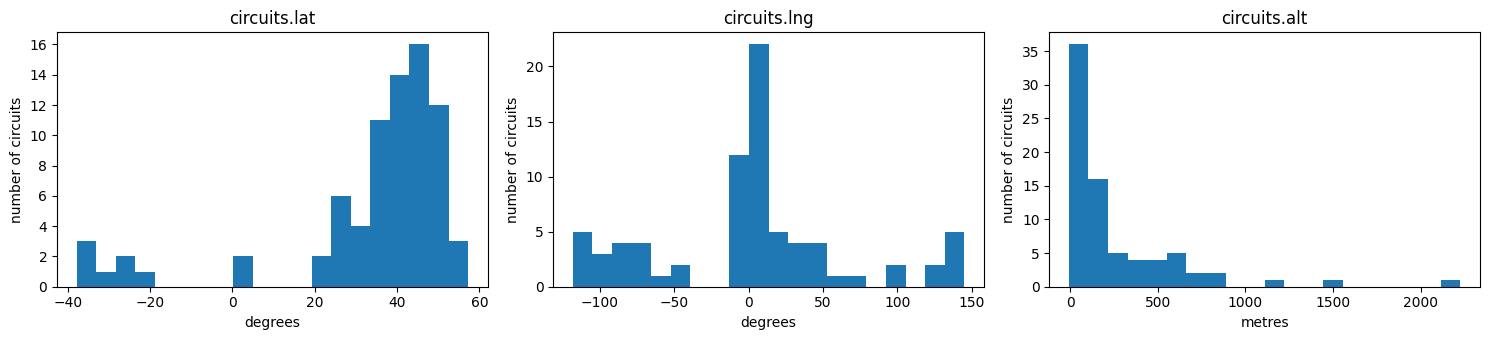

In [3]:
# ==========================================================================================
# A2 · circuits: profile, keys, types and basic sanity of every column
# ==========================================================================================

# An exploring copy of circuits: \N -> NaN and number columns -> numbers (raw stays untouched)
ci = as_num(raw["circuits"])

# ---------- 1. Profile card: one row per column ----------
# Shows, for each column, how many \N there are, how many different values, and an example value
display(profile("circuits"))

# ---------- 2. Keys: does circuitId identify every row? Are the other identifiers unique too? ----------
print(pk_check("circuits", ["circuitId"]))
print("circuitRef unique:", ci.circuitRef.is_unique, "| name unique:", ci.name.is_unique, "| url unique:", ci.url.is_unique)

# ---------- 3. Types: which columns became numbers, which stayed text? ----------
print(ci.dtypes)

# ---------- 4. Do the coordinates make sense? ----------
# Latitude must be between -90 and 90 and longitude between -180 and 180; altitude is in metres above sea level
display(ci[["lat", "lng", "alt"]].describe().round(2))
print("lat within [-90, 90]:", ci.lat.between(-90, 90).all(), "| lng within [-180, 180]:", ci.lng.between(-180, 180).all())
for col in ["lat", "lng", "alt"]:                                  # which circuit sits at each extreme?
    lo, hi = ci.loc[ci[col].idxmin()], ci.loc[ci[col].idxmax()]
    print(f"{col}: min {lo[col]} ({lo['name']}, {lo['country']}) | max {hi[col]} ({hi['name']}, {hi['country']})")

# ---------- 5. Text hygiene: stray spaces, naming pattern, accented letters, link format ----------
text_cols = ["circuitRef", "name", "location", "country", "url"]
print("values with leading/trailing spaces:", {c: int((ci[c] != ci[c].str.strip()).sum()) for c in text_cols})
bad_ref = ci.circuitRef[~ci.circuitRef.str.match(r"^[a-z0-9_]+$")]    # refs are normally lower_case_with_underscores
print("circuitRef values breaking the usual pattern:", bad_ref.tolist())
has_accent = ci.name.map(lambda s: not s.isascii())                    # True when a name has a non-English letter (é, ü, ...)
print("names with accented letters (they must display correctly):", ci.name[has_accent].tolist()[:4])
print("url starting with https:", ci.url.str.startswith("https").sum(), "| with http:", ci.url.str.startswith("http:").sum())

# ---------- 6. Plot: how latitude, longitude and altitude are spread (saved for the report) ----------
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
for a, col, unit in zip(ax, ["lat", "lng", "alt"], ["degrees", "degrees", "metres"]):
    ci[col].plot.hist(bins=20, ax=a, title=f"circuits.{col}")
    a.set_xlabel(unit)
    a.set_ylabel("number of circuits")
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/A2_circuit_coordinates.png", dpi=120, bbox_inches="tight")
plt.show()

**A2 result:**
- 77 circuits, 9 columns, with **no `\N` and no empty cells at all**: nothing to fill in.
- `circuitId` is a valid primary key, and `circuitRef`, `name` and `url` are unique too.
- Types are right: `circuitId`, `lat`, `lng` and `alt` are numbers; everything else is text.
- Every coordinate is physically possible: latitude runs from −37.85 (Albert Park, Australia) to 57.27 (Scandinavian Raceway, Sweden), and altitude from −7 m (Baku, below sea level) to 2,227 m (Mexico City).
- Text is clean: no stray spaces, and accented names (Autódromo, Nürburgring) are read correctly. Two cosmetic quirks: the `circuitRef` "ain-diab" uses a hyphen instead of an underscore, and 1 of the 77 links uses https while the rest use http.

**Decisions for cleaning:** nothing needs fixing here; keep `circuitId` as the only join key (never join on name or ref); `url` is not needed; altitude gets a closer look in A3.

## A3 · circuits: how often each was used, and where

- **What:** join `circuits` to `races` to count how many Grands Prix each circuit hosted and in which seasons, split the count into the eras "up to 2013" and "from 2014", check whether a circuit ever hosts two races in one season, and plot where the circuits are.
- **Why:** question 1 ranks circuits by how often a front-row start becomes a podium, before and after 2014. A circuit with 3 races cannot be ranked fairly against one with 70, so we must know how many races each circuit has, and how many circuits exist in *both* eras, before we choose a minimum-sample rule.

Circuits that never hosted a race: 0 | hosted exactly one race: 11


,name,races,first,last
13,Autodromo Nazionale di Monza,74,1950,2024
5,Circuit de Monaco,70,1950,2024
8,Silverstone Circuit,59,1950,2024
12,Circuit de Spa-Francorchamps,57,1950,2024
6,Circuit Gilles Villeneuve,43,1978,2024


,name,country,first
30,Donington Park,UK,1993
41,Fair Park,USA,1984
53,Le Mans,France,1967
56,Zeltweg,Austria,1964
59,Riverside International Raceway,USA,1960
60,AVUS,Germany,1959
61,Monsanto Park Circuit,Portugal,1959
62,Sebring International Raceway,USA,1959
63,Ain Diab,Morocco,1958
64,Pescara Circuit,Italy,1957


Circuits used up to 2013: 69 | from 2014: 32
Used in both eras: 24 | only up to 2013: 45 | only from 2014: 8
Circuits that first appear from 2014: ['Sochi Autodrom', 'Baku City Circuit', 'Autódromo Internacional do Algarve', 'Autodromo Internazionale del Mugello', 'Jeddah Corniche Circuit', 'Losail International Circuit', 'Miami International Autodrome', 'Las Vegas Strip Street Circuit']


,at least 1 races,at least 5 races,at least 10 races
up to 2013,69,45,30
from 2014,32,19,11
in BOTH eras,24,16,8


Seasons where one circuit hosted 2 or more races: [2020, 2021]
Circuits that hosted more than one differently named Grand Prix: 12 | most names at one circuit: 4 -> Nürburgring
Circuits with altitude exactly 0 m: [['yeongam', 'Yeongam County'], ['miami', 'Miami']]
Lowest 4 altitudes: [['baku', -7], ['yeongam', 0], ['miami', 0], ['sochi', 2]]


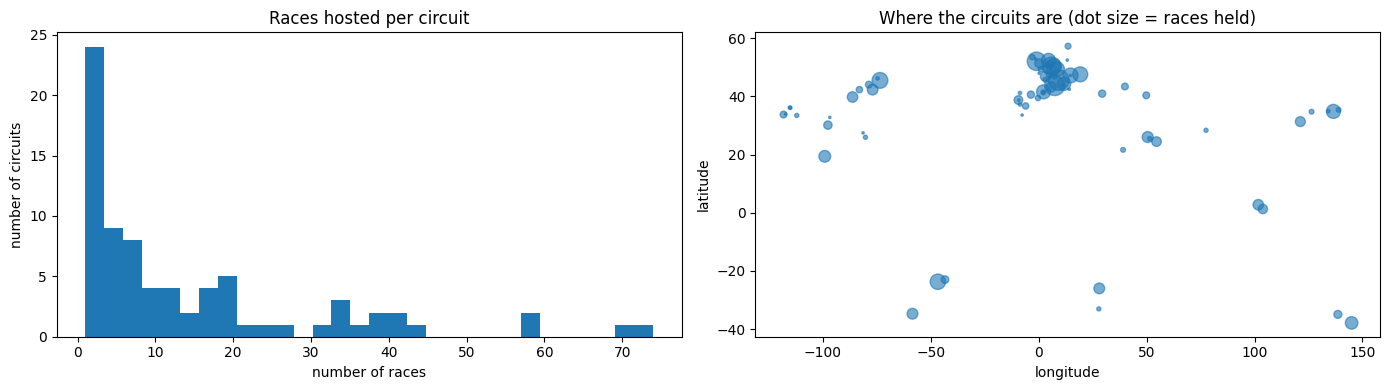

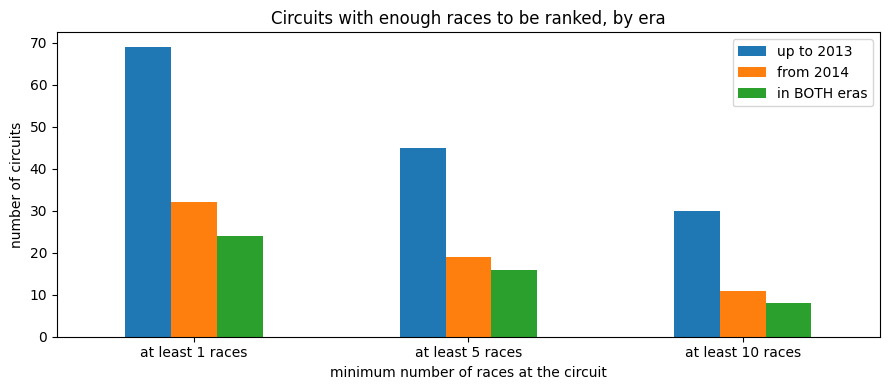

In [4]:
# ==========================================================================================
# A3 · circuits + races: how often was each circuit used, when, and where?
# ==========================================================================================

# Why: question 1 ranks circuits, so we need to know how many races each circuit hosted.
# A circuit with only 3 races cannot be ranked fairly against one with 70.
ci = as_num(raw["circuits"])          # exploring copy of circuits (raw stays untouched)

# ---------- 1. For every circuit: how many races, first season, last season ----------
rc = races.groupby("circuitId").agg(races=("raceId", "size"),      # number of Grands Prix held there
                                    first=("year", "min"),         # first season at this circuit
                                    last=("year", "max"))          # last season at this circuit
ci2 = ci.merge(rc, left_on="circuitId", right_index=True, how="left")   # attach the counts to the circuits table (a copy)

print("Circuits that never hosted a race:", ci2.races.isna().sum(),
      "| hosted exactly one race:", (ci2.races == 1).sum())
display(ci2.nlargest(5, "races")[["name", "races", "first", "last"]])      # the 5 most used circuits
display(ci2[ci2.races == 1][["name", "country", "first"]])                 # the one-off circuits

# ---------- 2. Before and after 2014: which circuits were used? ----------
# Question 1 compares the era up to 2013 with the era from 2014 on, so we count races per circuit in each era
n_early = races[races.year <= 2013].groupby("circuitId").size()    # races per circuit, seasons up to 2013
n_modern = races[races.year >= 2014].groupby("circuitId").size()   # races per circuit, seasons from 2014
both = sorted(set(n_early.index) & set(n_modern.index))            # circuits used in BOTH eras
print("Circuits used up to 2013:", len(n_early), "| from 2014:", len(n_modern))
print("Used in both eras:", len(both),
      "| only up to 2013:", len(n_early) - len(both), "| only from 2014:", len(n_modern) - len(both))
new_circuits = sorted(set(n_modern.index) - set(n_early.index))     # circuits that appear for the first time after 2013
print("Circuits that first appear from 2014:", ci.set_index("circuitId").name.reindex(new_circuits).tolist())

# How many circuits have enough races to be ranked? (at least 1, 5 or 10 races)
enough = pd.DataFrame(
    {f"at least {k} races": [int((n_early >= k).sum()), int((n_modern >= k).sum()),
                             int(((n_early.reindex(both) >= k) & (n_modern.reindex(both) >= k)).sum())]
     for k in [1, 5, 10]},
    index=["up to 2013", "from 2014", "in BOTH eras"])
display(enough)

# ---------- 3. Does a circuit ever host two races in the same season? ----------
per_season = races.groupby("year").agg(races=("raceId", "size"), circuits=("circuitId", "nunique"))
repeat = per_season[per_season.races > per_season.circuits]        # seasons with fewer circuits than races
print("Seasons where one circuit hosted 2 or more races:", repeat.index.tolist())

# ---------- 4. Does one circuit host Grands Prix with different names? ----------
names_per_circuit = races.groupby("circuitId").name.nunique()      # how many different race names per circuit
print("Circuits that hosted more than one differently named Grand Prix:", int((names_per_circuit > 1).sum()),
      "| most names at one circuit:", int(names_per_circuit.max()),
      "->", ci.set_index("circuitId").name[names_per_circuit.idxmax()])

# ---------- 5. Altitude: how many circuits sit at or near sea level? ----------
print("Circuits with altitude exactly 0 m:", ci[ci.alt == 0][["circuitRef", "location"]].values.tolist())
print("Lowest 4 altitudes:", ci.sort_values("alt")[["circuitRef", "alt"]].head(4).values.tolist())

# ---------- 6. Plots (saved for the report) ----------
os.makedirs("figures", exist_ok=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ci2.races.plot.hist(bins=30, ax=ax[0], title="Races hosted per circuit")
ax[0].set_xlabel("number of races")
ax[0].set_ylabel("number of circuits")
ax[1].scatter(ci2.lng, ci2.lat, s=ci2.races * 3, alpha=.6)        # each circuit is a dot; a bigger dot = more races
ax[1].set_title("Where the circuits are (dot size = races held)")
ax[1].set_xlabel("longitude")
ax[1].set_ylabel("latitude")
plt.tight_layout()
plt.savefig("figures/A3_circuit_usage.png", dpi=120, bbox_inches="tight")
plt.show()

enough.T.plot.bar(figsize=(9, 4), rot=0, title="Circuits with enough races to be ranked, by era")
plt.xlabel("minimum number of races at the circuit")
plt.ylabel("number of circuits")
plt.tight_layout()
plt.savefig("figures/A3_circuits_by_era.png", dpi=120, bbox_inches="tight")
plt.show()

**A3 result:**
- Every one of the 77 circuits hosted at least one race. **11 hosted exactly one** (for example Donington Park and Pescara). The most used are Monza (74 races), Monaco (70), Silverstone (59), Spa (57) and Circuit Gilles Villeneuve (43).
- **The ranking pool shrinks after 2013:** 69 circuits were used up to 2013 but only 32 from 2014. Just **24 circuits appear in both eras**; 45 disappeared and 8 are new (Sochi, Baku, Algarve, Mugello, Jeddah, Losail, Miami, Las Vegas).
- Requiring at least 5 races in each era leaves only **16 circuits** for the before/after comparison, and at least 10 races leaves only **8**.
- **One circuit can host two races in a season:** this happened in 2020 (Red Bull Ring, Silverstone, Bahrain) and 2021, so `(year, circuitId)` does **not** identify a single race.
- 12 circuits hosted Grands Prix under different names (the Nürburgring under 4), so Q1 must group by `circuitId`, not by race name.
- Altitude: Baku is below sea level (−7 m); Yeongam and Miami are exactly 0 m, which may be a real near-sea-level value or a default.

**Decisions for cleaning and Q1:** group circuits by `circuitId` only; set a minimum number of races before a circuit is ranked and say which (5 per era keeps 16 circuits for the comparison); never assume one race per circuit per season; if altitude is ever used, flag `alt = 0` as possibly unknown.

## A4 · circuits: country names, for question 2

- **What:** list every country spelling in `circuits` with its number of circuits and races, look for abbreviations and for two spellings of the same country, and test whether circuit countries can be matched directly to driver nationalities.
- **Why:** question 2 asks whether drivers podium more often at **home**. A home race is one where the driver's nationality matches the circuit's country, so before we can build that match we must know exactly how both sides are written. If the spellings are inconsistent, some home races would be silently missed.

Different country spellings: 35


,circuits,races
country,,
Italy,4,107
Germany,3,79
UK,4,79
USA,11,77
Monaco,1,70
Belgium,3,69
France,7,63
Spain,6,61
Canada,3,53


Abbreviated country names: ['UK', 'USA', 'UAE']
Both 'USA' and 'United States' present: True


,circuitRef,location,country
18,indianapolis,Indianapolis,USA
32,phoenix,Phoenix,USA
36,detroit,Detroit,USA
41,dallas,Dallas,USA
42,long_beach,California,USA
43,las_vegas,Nevada,USA
45,watkins_glen,New York State,USA
59,riverside,California,USA
62,sebring,Florida,USA
68,americas,Austin,USA


Countries before merging: 35 | after merging 'United States' into 'USA': 34
Circuits in the USA after merging: 12
Circuit countries spelled exactly like a driver nationality: [] (0 of 35)
Examples of the mismatch: circuits say ['UK', 'Germany', 'Monaco'] | drivers say ['British', 'German', 'Monegasque']


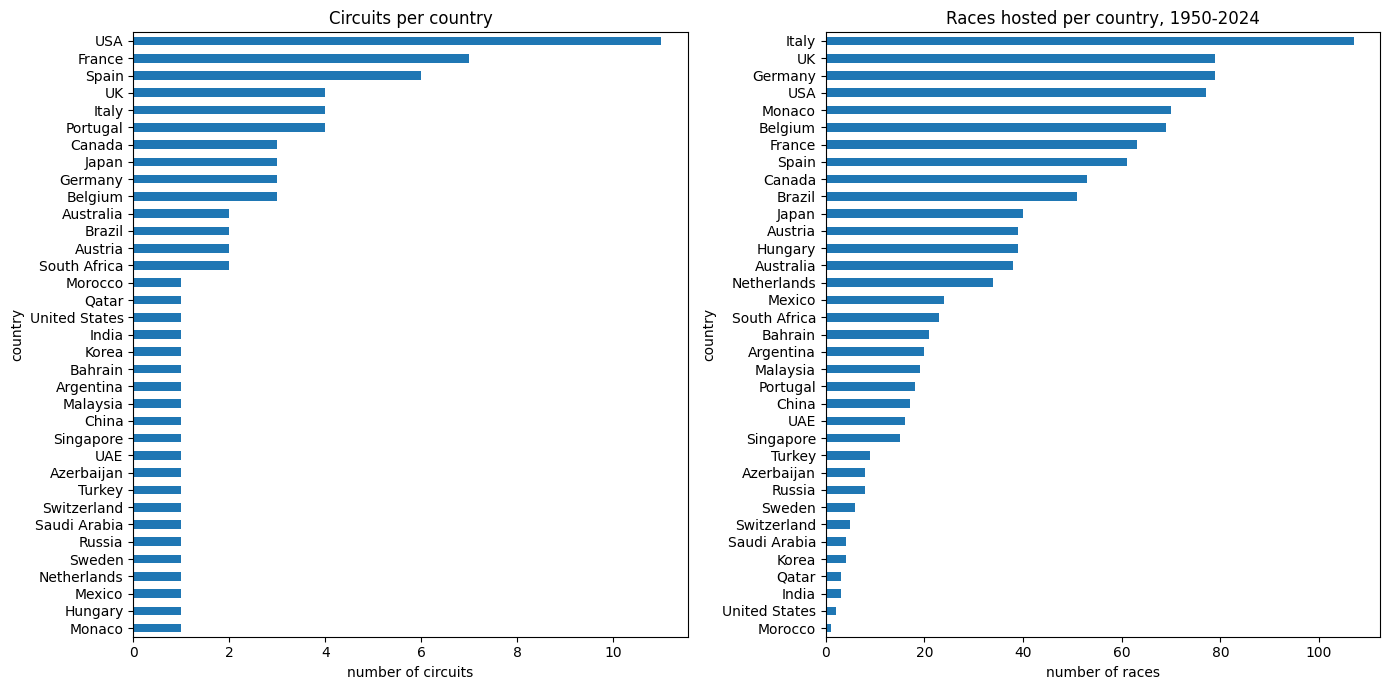

In [5]:
# ==========================================================================================
# A4 · circuits + drivers: how are countries spelled, and can they be matched to driver nationalities?
# ==========================================================================================

# Why: question 2 asks "do drivers podium more at HOME?". A home race is one where the driver's nationality
# matches the circuit's country, so before we can build that match we must know how both sides are written.
ci = as_num(raw["circuits"])          # exploring copy of circuits (raw stays untouched)
dr = as_num(raw["drivers"])           # exploring copy of drivers, only to compare the two vocabularies

# ---------- 1. Every country spelling, with how many circuits and races it has ----------
races_per_country = (races.merge(ci[["circuitId", "country"]], on="circuitId")   # give every race its circuit's country
                          .groupby("country").size().rename("races"))
country_table = (ci.groupby("country").size().rename("circuits").to_frame()       # circuits per country
                   .join(races_per_country)                                       # add races per country
                   .sort_values("races", ascending=False))
print("Different country spellings:", len(country_table))
display(country_table)

# ---------- 2. Which spellings are abbreviations, or two spellings of the same country? ----------
abbreviations = [c for c in country_table.index if c.isupper() and len(c) <= 3]   # UK, UAE, USA ...
print("Abbreviated country names:", abbreviations)
print("Both 'USA' and 'United States' present:", {"USA", "United States"} <= set(country_table.index))
display(ci[ci.country.isin(["USA", "United States"])][["circuitRef", "location", "country"]].sort_values("country"))

# ---------- 3. What happens if we merge those two spellings? ----------
usa_fixed = ci.country.replace({"United States": "USA"})          # a copy; the raw table is untouched
print("Countries before merging:", ci.country.nunique(), "| after merging 'United States' into 'USA':", usa_fixed.nunique())
print("Circuits in the USA after merging:", int((usa_fixed == "USA").sum()))

# ---------- 4. Can we simply join circuit countries to driver nationalities? ----------
# A home race needs "British driver" <-> "UK circuit". We test whether the words are ever identical.
same_words = sorted(set(ci.country) & set(dr.nationality))
print("Circuit countries spelled exactly like a driver nationality:", same_words, f"({len(same_words)} of {ci.country.nunique()})")
print("Examples of the mismatch: circuits say", ["UK", "Germany", "Monaco"], "| drivers say", ["British", "German", "Monegasque"])

# ---------- 5. Plot: where F1 circuits are, and where the races were (saved for the report) ----------
os.makedirs("figures", exist_ok=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 7))
country_table.circuits.sort_values().plot.barh(ax=ax[0], title="Circuits per country")
ax[0].set_xlabel("number of circuits")
country_table.races.sort_values().plot.barh(ax=ax[1], title="Races hosted per country, 1950-2024")
ax[1].set_xlabel("number of races")
plt.tight_layout()
plt.savefig("figures/A4_circuits_per_country.png", dpi=120, bbox_inches="tight")
plt.show()

**A4 result:**
- The table has **35 country spellings**. Italy hosted the most races (107), then the UK and Germany (79 each); Monaco hosted 70 from a single circuit.
- Three names are **abbreviations** (`UK`, `USA`, `UAE`), and `Korea` is a short form.
- **The USA is spelled two ways.** Eleven circuits say `USA`, but the newer Las Vegas Strip circuit says `United States` (only 2 races). Merging them gives **34 countries**, **12 US circuits** and 79 US races, the same as the UK and Germany.
- **The two sides never match as written:** 0 of the 35 circuit countries are spelled like a driver nationality (circuits say "UK", "Germany", "Monaco"; drivers say "British", "German", "Monegasque"). A direct join would find **no home races at all**.

**Decisions for cleaning and Q2:** merge `United States` into `USA` (or map both); join on `country` only, never on `location` (A2 showed two cities repeat); build a written nationality-to-country map as a table in the notebook (started in A7, finished in the Q2 task), and report how many countries have no matching driver nationality.